Loading dataset from ./data/validation-*.parquet...

Loading Standard ViT (Small)...

Starting Custom Threshold Dropping Sweep


Evaluating Retention=25.0%: 100%|██████████| 782/782 [01:07<00:00, 11.54it/s]



Custom Sweep Complete! Final Data:
Retention: 100% | Accuracy: 74.63% | Latency: 77.66 ms
Retention:  75% | Accuracy: 68.93% | Latency: 80.10 ms
Retention:  50% | Accuracy: 53.20% | Latency: 84.49 ms
Retention:  25% | Accuracy: 23.35% | Latency: 83.59 ms

[Success] Graph saved to 'custom_masking_pareto.png'!


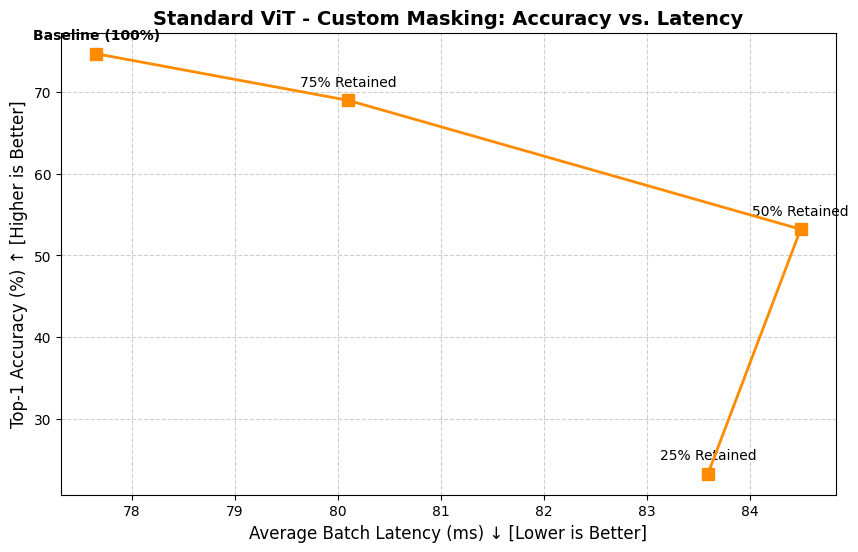

In [1]:
import torch
import timm
import time
import matplotlib.pyplot as plt
from datasets import load_dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

# --- Configuration ---
DATA_FILES = "./data/validation-*.parquet" 
BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The retention ratios specified in your proposal (plus 1.0 for baseline)
RETENTION_RATIOS = [1.0, 0.75, 0.50, 0.25]
DROP_LAYER_IDX = 5 # Apply the drop after the 6th block (0-indexed)

def get_dataloader():
    print(f"Loading dataset from {DATA_FILES}...")
    dataset = load_dataset("parquet", data_files=DATA_FILES, split="train")
    
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    def preprocess(examples):
        images = [val_transform(img.convert('RGB')) for img in examples['image']]
        return {'image': images, 'label': examples['label']}

    dataset = dataset.with_transform(preprocess)
    return DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

class MaskingTokenDropper:
    """
    A hook class that applies a binary mask to drop tokens 
    without changing the tensor shape.
    """
    def __init__(self, keep_ratio):
        self.keep_ratio = keep_ratio
        self.handle = None

    def hook_fn(self, module, input, output):
        if self.keep_ratio >= 1.0:
            return output # Do nothing for 100% retention

        # output shape is usually (Batch, Seq_Len, Dim) for ViT
        B, N, C = output.shape
        
        # 1. Calculate Token Importance
        # Since getting raw attention maps from timm requires deep model patching,
        # a standard proxy for token importance is the L2 norm of the token embedding itself.
        # We exclude the CLS token (index 0) from being dropped.
        patch_tokens = output[:, 1:, :] 
        importance = torch.norm(patch_tokens, p=2, dim=-1) # Shape: (Batch, Seq_Len - 1)
        
        # 2. Determine threshold for keeping tokens
        num_keep = int((N - 1) * self.keep_ratio)
        
        # 3. Create Binary Mask
        # Get the threshold value for the top-k tokens
        if num_keep > 0:
            threshold_values, _ = torch.kthvalue(importance, (N - 1) - num_keep + 1, dim=-1, keepdim=True)
            # 1.0 for keep, 0.0 for drop
            mask = (importance >= threshold_values).float() 
        else:
            mask = torch.zeros_like(importance)

        # Expand mask to match embedding dimension: (Batch, Seq_Len - 1, Dim)
        mask = mask.unsqueeze(-1).expand(-1, -1, C)
        
        # 4. Apply Mask to Patch Tokens
        masked_patches = patch_tokens * mask
        
        # 5. Reattach untouched CLS token
        cls_token = output[:, 0:1, :]
        masked_output = torch.cat([cls_token, masked_patches], dim=1)
        
        return masked_output

def evaluate_model(model, dataloader, ratio):
    model.eval()
    correct = 0
    total = 0
    timings = []
    
    use_cuda_timing = DEVICE.type == 'cuda'
    if use_cuda_timing:
        starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc=f"Evaluating Retention={ratio*100}%")):
            inputs = batch['image'].to(DEVICE)
            targets = batch['label'].to(DEVICE)

            if i > 5:
                if use_cuda_timing:
                    starter.record()
                else:
                    start_time = time.time()
                    
            outputs = model(inputs)
            
            if i > 5:
                if use_cuda_timing:
                    ender.record()
                    torch.cuda.synchronize()
                    timings.append(starter.elapsed_time(ender))
                else:
                    timings.append((time.time() - start_time) * 1000)

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    top1_acc = 100. * correct / total
    avg_latency_ms = sum(timings) / len(timings) if timings else 0 
    throughput = (BATCH_SIZE / avg_latency_ms) * 1000 if avg_latency_ms > 0 else 0
    
    return top1_acc, avg_latency_ms, throughput

def plot_custom_pareto(results):
    plt.figure(figsize=(10, 6))
    
    ratios = list(results.keys())
    accuracies = [results[r]["Accuracy"] for r in ratios]
    latencies = [results[r]["Latency (ms)"] for r in ratios]
    
    plt.plot(latencies, accuracies, marker='s', linestyle='-', color='darkorange', linewidth=2, markersize=8, zorder=5)
    
    for r, acc, lat in zip(ratios, accuracies, latencies):
        label = "Baseline (100%)" if r == 1.0 else f"{int(r*100)}% Retained"
        plt.annotate(
            label, 
            (lat, acc), 
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center', 
            fontsize=10,
            fontweight='bold' if r == 1.0 else 'normal'
        )
        
    plt.title("Standard ViT - Custom Masking: Accuracy vs. Latency", fontsize=14, fontweight='bold')
    plt.xlabel("Average Batch Latency (ms) ↓ [Lower is Better]", fontsize=12)
    plt.ylabel("Top-1 Accuracy (%) ↑ [Higher is Better]", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    output_filename = "custom_masking_pareto.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"\n[Success] Graph saved to '{output_filename}'!")

def main():
    dataloader = get_dataloader()
    
    print("\nLoading Standard ViT (Small)...")
    model = timm.create_model('vit_small_patch16_224', pretrained=True).to(DEVICE)
    
    # Identify the target layer to apply the hook
    # For timm's ViT, blocks are stored in model.blocks
    target_layer = model.blocks[DROP_LAYER_IDX]
    
    results = {}

    print(f"\n{'='*50}")
    print("Starting Custom Threshold Dropping Sweep")
    print(f"{'='*50}")

    for ratio in RETENTION_RATIOS:
        # Create a new dropper logic for this ratio
        dropper = MaskingTokenDropper(keep_ratio=ratio)
        
        # Register the hook to intercept the output of the target layer
        handle = target_layer.register_forward_hook(dropper.hook_fn)
        
        # Run evaluation
        acc, lat, thru = evaluate_model(model, dataloader, ratio)
        results[ratio] = {"Accuracy": acc, "Latency (ms)": lat, "Throughput": thru}
        
        # VERY IMPORTANT: Remove the hook before the next loop iteration
        # so they don't stack on top of each other!
        handle.remove()

    print(f"\n{'='*50}")
    print("Custom Sweep Complete! Final Data:")
    print(f"{'='*50}")
    for r, metrics in results.items():
        print(f"Retention: {r*100:>3.0f}% | Accuracy: {metrics['Accuracy']:>5.2f}% | Latency: {metrics['Latency (ms)']:>5.2f} ms")

    plot_custom_pareto(results)

if __name__ == "__main__":
    main()